In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
team_matches = pd.read_csv("../data/processed/team_matches.csv")
team_matches.head()

,date,team,opponent,goals_for,goals_against,tournament,city,country,neutral,is_home,result,points,goal_difference
0,2012-09-25,Abkhazia,Artsakh,1.0,1.0,Friendly,Sukhumi,Georgia,False,True,draw,1,0.0
1,2012-10-21,Abkhazia,Artsakh,0.0,3.0,Friendly,Stepanakert,Azerbaijan,False,False,loss,0,-3.0
2,2013-09-23,Abkhazia,South Ossetia,3.0,0.0,Friendly,Sukhumi,Georgia,False,True,win,3,3.0
3,2014-06-01,Abkhazia,Occitania,1.0,1.0,CONIFA World Football Cup,Östersund,Sweden,True,True,draw,1,0.0
4,2014-06-02,Abkhazia,Sápmi,2.0,1.0,CONIFA World Football Cup,Östersund,Sweden,False,False,win,3,1.0


In [3]:
team_matches["date"] = pd.to_datetime(team_matches["date"])
team_matches = team_matches.sort_values(["team", "date"]).reset_index(drop=True)
team_matches.head()

,date,team,opponent,goals_for,goals_against,tournament,city,country,neutral,is_home,result,points,goal_difference
0,2012-09-25,Abkhazia,Artsakh,1.0,1.0,Friendly,Sukhumi,Georgia,False,True,draw,1,0.0
1,2012-10-21,Abkhazia,Artsakh,0.0,3.0,Friendly,Stepanakert,Azerbaijan,False,False,loss,0,-3.0
2,2013-09-23,Abkhazia,South Ossetia,3.0,0.0,Friendly,Sukhumi,Georgia,False,True,win,3,3.0
3,2014-06-01,Abkhazia,Occitania,1.0,1.0,CONIFA World Football Cup,Östersund,Sweden,True,True,draw,1,0.0
4,2014-06-02,Abkhazia,Sápmi,2.0,1.0,CONIFA World Football Cup,Östersund,Sweden,False,False,win,3,1.0


In [4]:
team_matches["win"] = (team_matches["result"] == "win").astype(int)
team_matches["draw"] = (team_matches["result"] == "draw").astype(int)
team_matches["loss"] = (team_matches["result"] == "loss").astype(int)

In [5]:
team_matches[["team", "opponent", "result", "win", "draw", "loss"]].head(10)

,team,opponent,result,win,draw,loss
0,Abkhazia,Artsakh,draw,0,1,0
1,Abkhazia,Artsakh,loss,0,0,1
2,Abkhazia,South Ossetia,win,1,0,0
3,Abkhazia,Occitania,draw,0,1,0
4,Abkhazia,Sápmi,win,1,0,0
5,Abkhazia,South Ossetia,draw,0,1,0
6,Abkhazia,Padania,draw,0,1,0
7,Abkhazia,Occitania,loss,0,0,1
8,Abkhazia,Luhansk PR,win,1,0,0
9,Abkhazia,Donetsk PR,win,1,0,0


In [7]:
form_columns = [
    "points",
    "goals_for",
    "goals_against",
    "goal_difference",
    "win",
    "draw",
    "loss"
]

for col in form_columns:
    team_matches[f"last_5_{col}"] = (
        team_matches
        .groupby("team")[col]
        .transform(lambda x: x.shift(1).rolling(window=5, min_periods=1).sum())
    )

In [8]:
team_matches["previous_matches"] = (
    team_matches
    .groupby("team")
    .cumcount()
)

In [9]:
team_matches["form_matches_used"] = team_matches["previous_matches"].clip(upper=5)

In [10]:
team_matches["last_5_points_per_match"] = (
    team_matches["last_5_points"] / team_matches["form_matches_used"]
)

team_matches["last_5_goals_for_per_match"] = (
    team_matches["last_5_goals_for"] / team_matches["form_matches_used"]
)

team_matches["last_5_goals_against_per_match"] = (
    team_matches["last_5_goals_against"] / team_matches["form_matches_used"]
)

team_matches["last_5_goal_difference_per_match"] = (
    team_matches["last_5_goal_difference"] / team_matches["form_matches_used"]
)

In [11]:
team_matches[
    [
        "team",
        "date",
        "previous_matches",
        "last_5_points",
        "last_5_points_per_match"
    ]
].head(20)

,team,date,previous_matches,last_5_points,last_5_points_per_match
0,Abkhazia,2012-09-25,0,NaN,NaN
1,Abkhazia,2012-10-21,1,1.0,1.000000
2,Abkhazia,2013-09-23,2,1.0,0.500000
3,Abkhazia,2014-06-01,3,4.0,1.333333
4,Abkhazia,2014-06-02,4,5.0,1.250000
5,Abkhazia,2014-06-04,5,8.0,1.600000
6,Abkhazia,2014-06-05,6,8.0,1.600000
7,Abkhazia,2014-06-07,7,9.0,1.800000
8,Abkhazia,2015-05-05,8,6.0,1.200000
9,Abkhazia,2015-05-14,9,8.0,1.600000


In [12]:
team_matches.isna().sum()

date                                  0
team                                  0
opponent                              0
goals_for                           144
goals_against                       144
tournament                            0
city                                  0
country                               0
neutral                               0
is_home                               0
result                                0
points                                0
goal_difference                     144
win                                   0
draw                                  0
loss                                  0
last_5_points                       336
last_5_goals_for                    336
last_5_goals_against                336
last_5_goal_difference              336
last_5_win                          336
last_5_draw                         336
last_5_loss                         336
previous_matches                      0
form_matches_used                     0


In [16]:
form_feature_columns = [
    "last_5_points",
    "last_5_goals_for",
    "last_5_goals_against",
    "last_5_goal_difference",
    "last_5_win",
    "last_5_draw",
    "last_5_loss",
    "last_5_points_per_match",
    "last_5_goals_for_per_match",
    "last_5_goals_against_per_match",
    "last_5_goal_difference_per_match"
]

team_matches[form_feature_columns] = team_matches[form_feature_columns].fillna(0)

In [19]:
team_matches[team_matches["team"] == "Brazil"][
    [
        "date",
        "team",
        "opponent",
        "goals_for",
        "goals_against",
        "result",
        "points",
        "last_5_points",
        "last_5_points_per_match",
        "last_5_goals_for",
        "last_5_goals_against",
        "last_5_goal_difference"
    ]
].tail(15)

,date,team,opponent,goals_for,goals_against,result,points,last_5_points,last_5_points_per_match,last_5_goals_for,last_5_goals_against,last_5_goal_difference
11146,2025-06-05,Brazil,Ecuador,0.0,0.0,draw,1,8.0,1.6,9.0,7.0,2.0
11147,2025-06-10,Brazil,Paraguay,1.0,0.0,win,3,6.0,1.2,5.0,7.0,-2.0
11148,2025-09-04,Brazil,Chile,3.0,0.0,win,3,8.0,1.6,5.0,6.0,-1.0
11149,2025-09-09,Brazil,Bolivia,0.0,1.0,loss,0,10.0,2.0,7.0,5.0,2.0
11150,2025-10-10,Brazil,South Korea,5.0,0.0,win,3,7.0,1.4,5.0,5.0,0.0
11151,2025-10-14,Brazil,Japan,2.0,3.0,loss,0,10.0,2.0,9.0,1.0,8.0
11152,2025-11-15,Brazil,Senegal,2.0,0.0,win,3,9.0,1.8,11.0,4.0,7.0
11153,2025-11-18,Brazil,Tunisia,1.0,1.0,draw,1,9.0,1.8,12.0,4.0,8.0
11154,2026-03-26,Brazil,France,1.0,2.0,loss,0,7.0,1.4,10.0,5.0,5.0
11155,2026-03-31,Brazil,Croatia,3.0,1.0,win,3,7.0,1.4,11.0,6.0,5.0


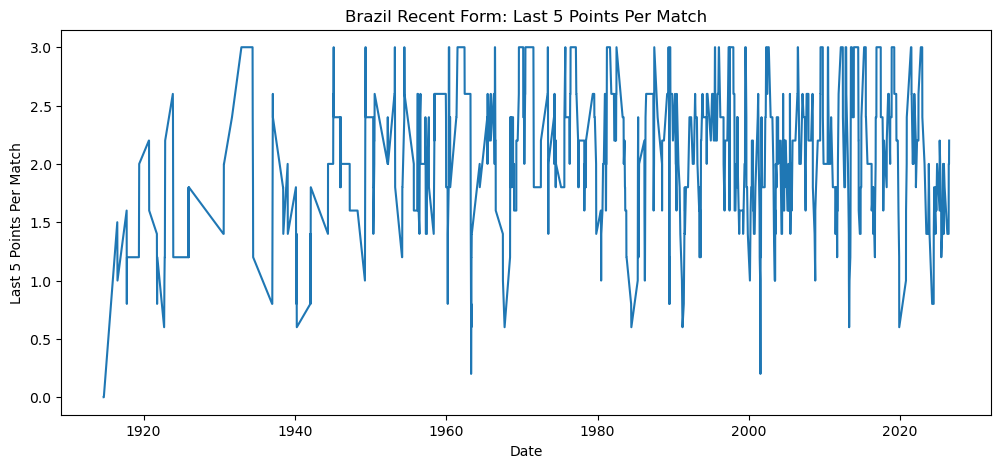

In [20]:
brazil = team_matches[team_matches["team"] == "Brazil"].copy()

plt.figure(figsize=(12, 5))
plt.plot(brazil["date"], brazil["last_5_points_per_match"])

plt.title("Brazil Recent Form: Last 5 Points Per Match")
plt.xlabel("Date")
plt.ylabel("Last 5 Points Per Match")
plt.show()

In [21]:
team_matches.to_csv("../data/processed/team_matches_with_form.csv", index=False)